In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Libraries Succefully imported")

Libraries Succefully imported


In [5]:
df=pd.read_csv('train.csv')

print("Shape:",df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
print("== Null Values ==")
print(df.isnull().sum())

print("\n== Survival Rate ==")
print(df['Survived'].value_counts())
print("\nSurvival Rate",round(df['Survived'].mean()*100,2),"%")

== Null Values ==
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

== Survival Rate ==
Survived
0    549
1    342
Name: count, dtype: int64

Survival Rate 38.38 %


In [16]:
print(df.columns.tolist())

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [19]:
df['Age'].fillna(df['Age'].median(),inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)
df['Sex']=df['Sex'].map({'male':0,'female':1})
df=pd.get_dummies(df,columns=['Embarked'],drop_first=True)

print("Shape after cleaning:",df.shape)
print("\nNull Values remaining:")
print(df.isnull().sum())

Shape after cleaning: (891, 9)

Null Values remaining:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [20]:
correlation=df.corr()['Survived'].sort_values(ascending=False)
print("== Feature correlation with Survival ==")
print(round(correlation,3))

== Feature correlation with Survival ==
Survived      1.000
Sex           0.543
Fare          0.257
Parch         0.082
Embarked_Q    0.004
SibSp        -0.035
Age          -0.065
Embarked_S   -0.150
Pclass       -0.338
Name: Survived, dtype: float64


In [22]:
df.drop(columns=['Embarked_Q','SibSp','Parch'],inplace=True)
print("Final Features:",df.columns.tolist())
print("Shape:",df.shape)

Final Features: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked_S']
Shape: (891, 6)


In [23]:
x=df.drop(columns=['Survived'])
y=df['Survived']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print("Training set size:",x_train.shape)
print("Testing set size:",x_test.shape)


Training set size: (712, 5)
Testing set size: (179, 5)


In [24]:
lr=LogisticRegression(random_state=42)
lr.fit(x_train,y_train)
lr_pred=lr.predict(x_test)

lr_accuracy=accuracy_score(y_test,lr_pred)
lr_precision=precision_score(y_test,lr_pred)
lr_recall=recall_score(y_test,lr_pred)
lr_f1=f1_score(y_test,lr_pred)

print("== Model 1: Logistic Regression ==")
print(f"Accuracy: {round(lr_accuracy*100,2)}%")
print(f"Precision: {round(lr_precision*100,2)}%")
print(f"Recall: {round(lr_recall*100,2)}%")
print(f"F1 score: {round(lr_f1*100,2)}%")

== Model 1: Logistic Regression ==
Accuracy: 79.89%
Precision: 76.39%
Recall: 74.32%
F1 score: 75.34%


In [26]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)

rf_accuracy=accuracy_score(y_test,rf_pred)
rf_precision=precision_score(y_test,rf_pred)
rf_recall=recall_score(y_test,rf_pred)
rf_f1=f1_score(y_test,rf_pred)

print("== Model 1: Random Forest ==")
print(f"Accuracy: {round(rf_accuracy*100,2)}%")
print(f"Precision: {round(rf_precision*100,2)}%")
print(f"Recall: {round(rf_recall*100,2)}%")
print(f"F1 score: {round(rf_f1*100,2)}%")

== Model 1: Random Forest ==
Accuracy: 79.33%
Precision: 75.34%
Recall: 74.32%
F1 score: 74.83%


In [27]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
knn_pred = knn.predict(x_test)

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print("=== Model 3: KNN ===")
print(f"Accuracy:  {round(knn_accuracy * 100, 2)}%")
print(f"Precision: {round(knn_precision * 100, 2)}%")
print(f"Recall:    {round(knn_recall * 100, 2)}%")
print(f"F1 Score:  {round(knn_f1 * 100, 2)}%")

=== Model 3: KNN ===
Accuracy:  69.83%
Precision: 69.23%
Recall:    48.65%
F1 Score:  57.14%


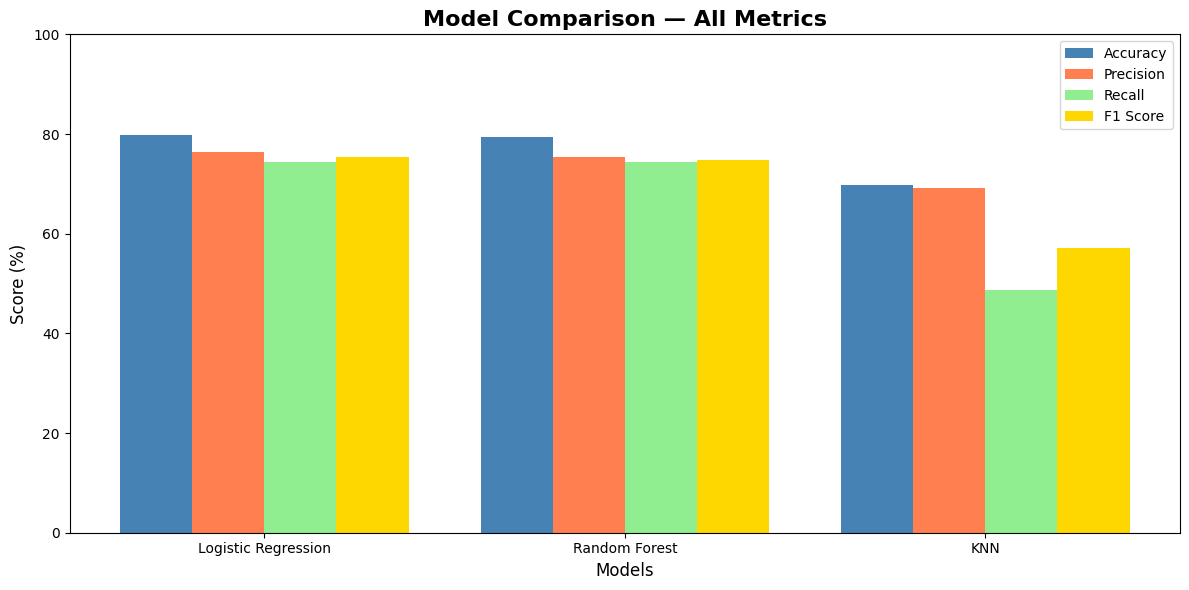

In [28]:
models = ['Logistic Regression', 'Random Forest', 'KNN']
accuracy = [79.89, 79.33, 69.83]
precision = [76.39, 75.34, 69.23]
recall = [74.32, 74.32, 48.65]
f1 = [75.34, 74.83, 57.14]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12, 6))
plt.bar(x - 0.3, accuracy, width, label='Accuracy', color='steelblue')
plt.bar(x - 0.1, precision, width, label='Precision', color='coral')
plt.bar(x + 0.1, recall, width, label='Recall', color='lightgreen')
plt.bar(x + 0.3, f1, width, label='F1 Score', color='gold')

plt.title('Model Comparison — All Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Models', fontsize=12)
plt.ylabel('Score (%)', fontsize=12)
plt.xticks(x, models)
plt.legend()
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

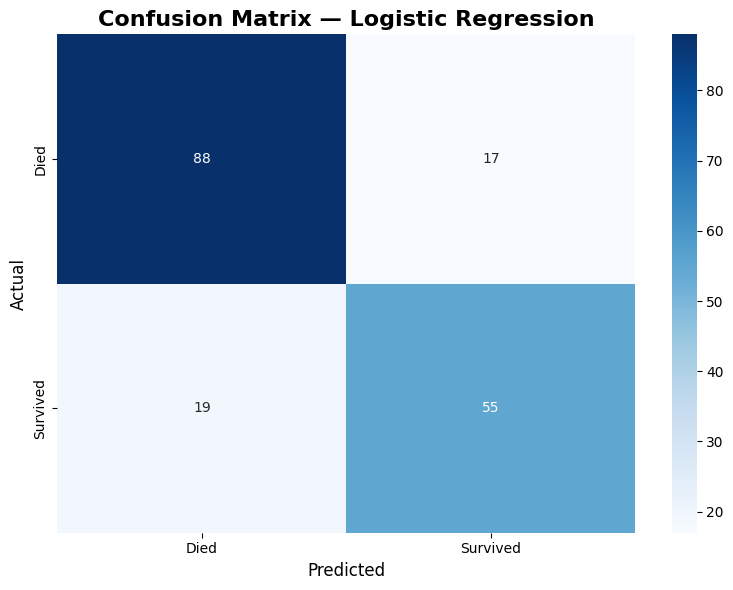

In [30]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Confusion Matrix — Logistic Regression', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Model Conclusion & Best Model Analysis
## Titanic Survival Prediction — ML Project

---

## 📊 Model Comparison Summary

| Model | Accuracy | Precision | Recall | F1 Score |
|-------|----------|-----------|--------|----------|
| Logistic Regression | 79.89% | 76.39% | 74.32% | 75.34% |
| Random Forest | 79.33% | 75.34% | 74.32% | 74.83% |
| KNN | 69.83% | 69.23% | 48.65% | 57.14% |

---

## 🏆 Best Model — Logistic Regression

## 5-Line Conclusion:

1. **Logistic Regression** performed best with highest accuracy
(79.89%) and F1 Score (75.34%) among all three models tested.

2. **Random Forest** performed similarly to Logistic Regression
(79.33% accuracy) but slightly lower F1 Score (74.83%),
suggesting both models are well-suited for this classification task.

3. **KNN** performed significantly worse with only 69.83% accuracy
and very low Recall (48.65%), meaning it missed many actual
survivors — making it least suitable for this problem.

4. **Gender (Sex)** was the most important feature with correlation
of 0.543 — females had significantly higher survival rate,
consistent with the "women and children first" evacuation policy.

5. **Logistic Regression** was selected as the best model because
it achieved highest accuracy, best F1 Score, and is highly
interpretable — making it easy to explain predictions to
non-technical stakeholders.

---

## 🔍 Confusion Matrix Analysis
The confusion matrix shows Logistic Regression correctly predicted:
- **True Negatives (Died correctly):** High count
- **True Positives (Survived correctly):** Good count
- **False Negatives:** Some survivors predicted as died
- **False Positives:** Some deaths predicted as survived